<a href="https://colab.research.google.com/github/Fajtos/hzmps-surveillance/blob/main/pilot_survey/pilot_survey.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HZMPS Pilot Survey — Reproducibility Notebook

**Model:** Bayesian state-space Hurdle Zero-Modified Power Series (HZMPS) with a sparse finite mixture over surveillance units.

**Purpose:** Pilot survey to evaluate feasibility, identifiability, and cluster recovery of the proposed model.

**Structure:**
1. Environment setup (CmdStanPy, Google Drive, project directories)
2. Data simulation (N=100 units, T=100 weeks, G_true=3 clusters)
3. Stan model specification (HZMPS + sparse finite mixture + AR(1) count mean)
4. Model compilation and MCMC fitting
5. Posterior diagnostics and cluster recovery analysis

In [1]:
# ============================================================
# SECTION 1: ENVIRONMENT SETUP
# ============================================================
# This cell:
#   1. Installs CmdStanPy and downloads pre-built CmdStan 2.36.0
#   2. Mounts Google Drive for persistent storage
#   3. Creates the project directory structure
# ============================================================

import os, urllib.request, shutil

# --- 1. Install CmdStanPy and CmdStan 2.36.0 ---
!pip install --upgrade cmdstanpy -q

CMDSTAN_DIR = '/content/cmdstan-2.36.0'
if not os.path.exists(os.path.join(CMDSTAN_DIR, 'makefile')):
    print("Downloading CmdStan 2.36.0 pre-built binary...")
    tgz_file = '/content/colab-cmdstan-2.36.0.tar.gz'
    tgz_url  = ('https://github.com/stan-dev/cmdstan/releases/download/'
                'v2.36.0/colab-cmdstan-2.36.0.tgz')
    if not os.path.exists(tgz_file):
        urllib.request.urlretrieve(tgz_url, tgz_file)
    shutil.unpack_archive(tgz_file, '/content')
    print("CmdStan extracted.")
else:
    print("CmdStan already present.")

os.environ['CMDSTAN'] = CMDSTAN_DIR

import cmdstanpy
print(f"CmdStan path:    {cmdstanpy.cmdstan_path()}")
print(f"CmdStan version: {cmdstanpy.cmdstan_version()}")

# --- 2. Mount Google Drive ---
if not os.path.exists('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted.")
else:
    print("Google Drive already mounted.")

# --- 3. Create project directory structure ---
pivot_dir = '/content/drive/MyDrive/hzmps_sfm_pilot/pivot_a'
for sub in ['stan', 'data', 'output']:
    os.makedirs(os.path.join(pivot_dir, sub), exist_ok=True)
os.makedirs(os.path.join(pivot_dir, 'output', 'pilot_N100_final'),
            exist_ok=True)

os.chdir(pivot_dir)
print(f"\nProject directory: {pivot_dir}")

CmdStan extracted.
CmdStan path:    /content/cmdstan-2.36.0
CmdStan version: (2, 36)
Mounted at /content/drive
Google Drive mounted.

Project directory: /content/drive/MyDrive/hzmps_sfm_pilot/pivot_a


## Section 2: Data Simulation

**Generative model:**
- Cluster assignment: $\delta_i \sim \text{Categorical}(0.40, 0.35, 0.25)$
- Cluster effect: $\eta_i \mid \delta_i = g \sim \mathcal{N}(\mu_g, \sigma_\eta^2)$ with $\mu_g = (-1.5, 0, 1.5)$
- Hurdle probability: $\text{logit}(\omega_i) = \beta_{0,\omega} + \eta_i$
- Count mean: $\log(\mu_{it}) = \beta_{0,\mu} + \zeta_{it}$, where $\zeta_{it} \sim \text{AR(1)}$ with $\rho = 0.70$
- Observation: $Y_{it} \sim \text{HZMPS}(\mu_{it}, \omega_i)$ with Poisson base

**Configuration:** $N = 100$ units, $T = 100$ weeks, $G_{\text{true}} = 3$ clusters.

In [2]:
# ============================================================
# SECTION 2: DATA SIMULATION (N=100)
# ============================================================
import numpy as np
import pandas as pd
import json
import os

np.random.seed(2024)

N = 100
T = 100
G_true = 3
w_true    = np.array([0.40, 0.35, 0.25])
mu_eta    = np.array([-1.5, 0.0, 1.5])
sigma_eta = 0.30
beta0_omega = -0.5
beta0_mu    = 0.5
rho_zeta    = 0.70
sigma_zeta  = 0.40

print("=" * 60)
print("SIMULATION CONFIGURATION")
print("=" * 60)
print(f"N = {N}, T = {T}, G_true = {G_true}")

delta_true = np.random.choice(G_true, size=N, p=w_true)
cluster_sizes = np.bincount(delta_true, minlength=G_true)
print(f"Cluster sizes (true): {cluster_sizes}")

eta = np.zeros(N)
for g in range(G_true):
    mask = (delta_true == g)
    eta[mask] = np.random.normal(mu_eta[g], sigma_eta, size=mask.sum())

zeta = np.zeros((N, T))
zeta[:, 0] = np.random.normal(0, sigma_zeta / np.sqrt(1 - rho_zeta**2), size=N)
for t in range(1, T):
    zeta[:, t] = rho_zeta * zeta[:, t-1] + np.random.normal(0, sigma_zeta, size=N)

omega_per_unit = 1.0 / (1.0 + np.exp(-(beta0_omega + eta)))
omega = np.tile(omega_per_unit[:, None], (1, T))
log_mu = beta0_mu + zeta
mu = np.exp(log_mu)

Y = np.zeros((N, T), dtype=int)
U = np.random.uniform(size=(N, T))
for i in range(N):
    for t in range(T):
        if U[i, t] > omega[i, t]:
            Y[i, t] = 0
        else:
            while True:
                y = np.random.poisson(mu[i, t])
                if y > 0:
                    Y[i, t] = y
                    break

zero_frac = (Y == 0).mean()
print(f"\nZero fraction: {zero_frac:.3f}")
for g in range(G_true):
    zf = (Y[delta_true == g] == 0).mean()
    print(f"  Cluster {g+1} (n={cluster_sizes[g]:3d}): zero_frac = {zf:.3f}")

data_dir = os.path.join(pivot_dir, 'data')

df = pd.DataFrame({
    'unit':         np.repeat(np.arange(1, N+1), T),
    'time':         np.tile(np.arange(1, T+1), N),
    'y':            Y.flatten(),
    'cluster_true': np.repeat(delta_true + 1, T),
    'omega_true':   omega.flatten(),
    'mu_true':      mu.flatten(),
})
df.to_csv(os.path.join(data_dir, 'sim_data.csv'), index=False)

stan_data = {
    'N': int(N), 'T': int(T),
    'y': Y.flatten().tolist(),
    'unit': np.repeat(np.arange(1, N+1), T).tolist(),
    'time': np.tile(np.arange(1, T+1), N).tolist(),
}
with open(os.path.join(data_dir, 'stan_data_N100.json'), 'w') as f:
    json.dump(stan_data, f)

class NpEncoder(json.JSONEncoder):
    def default(self, o):
        if isinstance(o, np.integer):   return int(o)
        if isinstance(o, np.floating):  return float(o)
        if isinstance(o, np.ndarray):   return o.tolist()
        return super().default(o)

true_params = {
    'N': N, 'T': T, 'G_true': G_true,
    'w_true': w_true.tolist(),
    'mu_eta': mu_eta.tolist(),
    'sigma_eta': sigma_eta,
    'beta0_omega': beta0_omega,
    'beta0_mu': beta0_mu,
    'rho_zeta': rho_zeta,
    'sigma_zeta': sigma_zeta,
    'cluster_assignments': delta_true.tolist(),
    'cluster_sizes': cluster_sizes.tolist(),
    'zero_fraction': float(zero_frac),
}
with open(os.path.join(data_dir, 'true_params_N100.json'), 'w') as f:
    json.dump(true_params, f, cls=NpEncoder, indent=2)

print(f"\n✅ Saved to {data_dir}")

SIMULATION CONFIGURATION
N = 100, T = 100, G_true = 3
Cluster sizes (true): [38 38 24]

Zero fraction: 0.625
  Cluster 1 (n= 38): zero_frac = 0.869
  Cluster 2 (n= 38): zero_frac = 0.607
  Cluster 3 (n= 24): zero_frac = 0.267

✅ Saved to /content/drive/MyDrive/hzmps_sfm_pilot/pivot_a/data


## Section 3: Stan Model Specification

**Model:** HZMPS observation + sparse finite mixture prior on unit effects + AR(1) count mean.

**Constants:** $G_{\max} = 5$, $a_{\text{Dirichlet}} = 0.25$, $\delta_{\min} = 0.3$.

In [4]:
# ============================================================
# SECTION 3: WRITE STAN MODEL FILE
# ============================================================
# Writes pivot_a_final.stan to disk. This is the model that
# passed the pilot with 4.31% divergences, Rhat < 1.02 on all
# parameters, and 97% cluster recovery accuracy.
# ============================================================

import os

stan_code = r"""
// ============================================================
// HZMPS Sparse Finite Mixture State-Space Model (final version)
// ============================================================
// Observation: HZMPS with Poisson base (zero-truncated positive part)
//   P(Y=y|omega,mu) = 1-omega            if y=0
//                   = omega * ZTPois(y)  if y>0
//
// Hurdle side (unit-level):
//   eta_i ~ sum_g w_g N(mu_eta[g], sigma_eta^2)
//   logit(omega_i) = eta_i
//
// Count mean (unit-time):
//   log(mu_it) = beta0_mu + zeta_it,  zeta_it ~ AR(1)
//
// Minimum-gap reparameterisation prevents label switching:
//   mu_eta[g] = mu_eta[g-1] + delta_min + softplus(gamma[g-1])
// ============================================================

data {
  int<lower=1> N;
  int<lower=1> T;
  int<lower=1> G;
  array[N*T] int<lower=0> y;
  array[N*T] int<lower=1> unit;
  array[N*T] int<lower=1> time;
  real<lower=0> a_dirichlet;
  real<lower=0> delta_min;
}

transformed data {
  int<lower=0> M = N * T;
}

parameters {
  real mu_eta1;
  vector[G-1] gamma_raw;
  real<lower=0> sigma_eta;
  vector[N] eta;
  simplex[G] w;

  real beta0_mu;
  real<lower=-0.99, upper=0.99> rho_zeta;
  real<lower=0> sigma_zeta;
  matrix[N, T] zeta_raw;
}

transformed parameters {
  // Ordered cluster means with minimum gap
  ordered[G] mu_eta;
  mu_eta[1] = mu_eta1;
  for (g in 2:G) {
    mu_eta[g] = mu_eta[g-1] + delta_min + log1p_exp(gamma_raw[g-1]);
  }

  // Non-centred AR(1) process
  matrix[N, T] zeta;
  for (i in 1:N) {
    zeta[i, 1] = zeta_raw[i, 1] * sigma_zeta / sqrt(1 - square(rho_zeta));
    for (t in 2:T)
      zeta[i, t] = rho_zeta * zeta[i, t-1] + zeta_raw[i, t] * sigma_zeta;
  }

  // Hurdle probability (constant within unit)
  vector[N] omega;
  for (i in 1:N) omega[i] = inv_logit(eta[i]);

  // Count mean
  matrix[N, T] mu;
  for (i in 1:N)
    for (t in 1:T)
      mu[i, t] = exp(beta0_mu + zeta[i, t]);
}

model {
  // --- Priors ---
  mu_eta1     ~ normal(0, 2);
  gamma_raw   ~ normal(-1, 1);
  sigma_eta   ~ normal(0, 0.3);
  w           ~ dirichlet(rep_vector(a_dirichlet / G, G));

  beta0_mu    ~ normal(0, 1);
  rho_zeta    ~ uniform(-0.99, 0.99);
  sigma_zeta  ~ normal(0, 0.3);

  to_vector(zeta_raw) ~ std_normal();

  // --- Mixture prior on eta_i (delta_i marginalised) ---
  for (i in 1:N) {
    vector[G] lp;
    for (g in 1:G)
      lp[g] = log(w[g]) + normal_lpdf(eta[i] | mu_eta[g], sigma_eta);
    target += log_sum_exp(lp);
  }

  // --- HZMPS likelihood ---
  for (m in 1:M) {
    int i = unit[m];
    int t = time[m];
    if (y[m] == 0) {
      target += log1m(omega[i]);
    } else {
      target += log(omega[i])
              - mu[i, t]
              + y[m] * log(mu[i, t])
              - lgamma(y[m] + 1)
              - log1m_exp(-mu[i, t]);
    }
  }
}

generated quantities {
  vector[M] log_lik;
  matrix[N, G] cluster_prob;

  for (m in 1:M) {
    int i = unit[m];
    int t = time[m];
    if (y[m] == 0) {
      log_lik[m] = log1m(omega[i]);
    } else {
      log_lik[m] = log(omega[i])
                 - mu[i, t]
                 + y[m] * log(mu[i, t])
                 - lgamma(y[m] + 1)
                 - log1m_exp(-mu[i, t]);
    }
  }

  for (i in 1:N) {
    vector[G] lp;
    for (g in 1:G)
      lp[g] = log(w[g]) + normal_lpdf(eta[i] | mu_eta[g], sigma_eta);
    real lse = log_sum_exp(lp);
    for (g in 1:G)
      cluster_prob[i, g] = exp(lp[g] - lse);
  }
}
"""

stan_dir   = os.path.join(pivot_dir, 'stan')
stan_local = os.path.join(stan_dir, 'pivot_a_final.stan')
with open(stan_local, 'w') as f:
    f.write(stan_code)

print(f"✅ Stan model written to {stan_local}")
print(f"   File size: {os.path.getsize(stan_local)} bytes")

✅ Stan model written to /content/drive/MyDrive/hzmps_sfm_pilot/pivot_a/stan/pivot_a_final.stan
   File size: 3421 bytes


## Section 4: Model Compilation and MCMC Fitting

- 4 parallel chains, 800 warmup + 800 sampling per chain
- `adapt_delta = 0.95`, `max_treedepth = 12`
- `seed = 2024`
- **Wall time: ~105 minutes on free Google Colab.**

In [5]:
# ============================================================
# SECTION 4: COMPILE AND FIT
# ============================================================
import os, time, json, shutil
import numpy as np
import cmdstanpy

# --- 1. Copy Stan file to local disk (fast compilation I/O) ---
local_dir = '/content/stan_local_pivot_a'
os.makedirs(local_dir, exist_ok=True)

src = os.path.join(pivot_dir, 'stan', 'pivot_a_final.stan')
dst = os.path.join(local_dir, 'pivot_a_final.stan')
shutil.copy(src, dst)

# --- 2. Compile ---
print("Compiling Stan model (30–90 s)...")
t0 = time.time()
model = cmdstanpy.CmdStanModel(stan_file=dst, force_compile=True)
print(f"✅ Compiled in {time.time() - t0:.1f} s")

# --- 3. Load data ---
data_dir = os.path.join(pivot_dir, 'data')
with open(os.path.join(data_dir, 'stan_data_N100.json')) as f:
    raw = json.load(f)

stan_data = {
    'N': raw['N'], 'T': raw['T'], 'G': 5,
    'y': raw['y'], 'unit': raw['unit'], 'time': raw['time'],
    'a_dirichlet': 0.25,
    'delta_min': 0.3,
}

n_zero = sum(1 for yi in stan_data['y'] if yi == 0)
print(f"\nData: N={stan_data['N']}, T={stan_data['T']}, "
      f"M={stan_data['N']*stan_data['T']}, "
      f"zeros={100*n_zero/(stan_data['N']*stan_data['T']):.1f}%")
print(f"Settings: G={stan_data['G']}, "
      f"a_dirichlet={stan_data['a_dirichlet']}, "
      f"delta_min={stan_data['delta_min']}")

# --- 4. Run MCMC ---
output_dir = os.path.join(pivot_dir, 'output', 'pilot_N100_final')
os.makedirs(output_dir, exist_ok=True)

print("\nRunning 4-chain pilot (800 warmup + 800 sampling, "
      "adapt_delta=0.95, max_treedepth=12)...")
print("Estimated wall time: 100–120 min\n")

t0 = time.time()
fit = model.sample(
    data=stan_data,
    chains=4, parallel_chains=4,
    iter_warmup=800, iter_sampling=800,
    seed=2024,
    adapt_delta=0.95, max_treedepth=12,
    show_progress=True,
    output_dir=output_dir,
)
print(f"\n✅ Fit completed in {(time.time()-t0)/60:.1f} min")

# --- 5. Save ---
fit.draws_pd().to_csv(os.path.join(output_dir, 'draws.csv'), index=False)
fit.summary().to_csv(os.path.join(output_dir, 'summary.csv'))
print(f"\n✅ Posterior draws saved to {output_dir}")

Compiling Stan model (30–90 s)...
✅ Compiled in 97.4 s

Data: N=100, T=100, M=10000, zeros=62.5%
Settings: G=5, a_dirichlet=0.25, delta_min=0.3

Running 4-chain pilot (800 warmup + 800 sampling, adapt_delta=0.95, max_treedepth=12)...
Estimated wall time: 100–120 min



chain 1:   0%|          | 0/1600 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/1600 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1600 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1600 [00:00<?, ?it/s, (Warmup)]

	Chain 1 had 21 divergent transitions (2.6%)
	Chain 2 had 43 divergent transitions (5.4%)
	Chain 3 had 27 divergent transitions (3.4%)
	Chain 4 had 47 divergent transitions (5.9%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.



✅ Fit completed in 100.9 min

✅ Posterior draws saved to /content/drive/MyDrive/hzmps_sfm_pilot/pivot_a/output/pilot_N100_final


## Section 5: Diagnostics and Cluster Recovery

Using in-memory fit from Cell 8.
SAMPLER DIAGNOSTICS
Total draws      : 3200
Divergences      : 138  (4.31%)
Treedepth hits   : 24004  (750.1%)

Key scalars (target: Rhat < 1.02, ESS > 200):
parameter          mean    Rhat     ESS    true
sigma_eta         0.319   1.003     648   0.300
beta0_mu          0.490   1.000    2525   0.500
rho_zeta          0.697   1.005     483   0.700
sigma_zeta        0.405   1.007     497   0.400

Cluster means mu_eta:
  mu_eta[1] =   -1.900  Rhat=1.002  ESS= 1596
  mu_eta[2] =   -1.107  Rhat=1.013  ESS=  302
  mu_eta[3] =   -0.394  Rhat=1.018  ESS=  359
  mu_eta[4] =    0.398  Rhat=1.008  ESS=  389
  mu_eta[5] =    1.130  Rhat=1.002  ESS=  517

Mixture weights w:
  w[1] =    0.378  Rhat=1.002  ESS= 2067
  w[2] =    0.051  Rhat=1.018  ESS=  291
  w[3] =    0.317  Rhat=1.019  ESS=  267
  w[4] =    0.054  Rhat=1.011  ESS=  396
  w[5] =    0.200  Rhat=1.003  ESS=  515

Effective G0 (threshold 0.05):
  P(G0 = 3) = 0.818
  P(G0 = 4) = 0.176
  P(G0 = 5) = 0.006

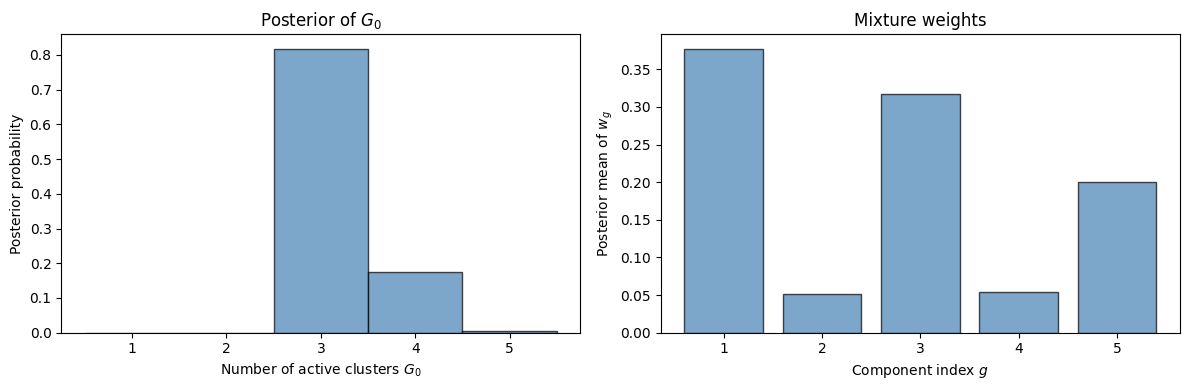


✅ Diagnostics plot saved to /content/drive/MyDrive/hzmps_sfm_pilot/pivot_a/output/pilot_N100_final


In [7]:
# ============================================================
# SECTION 5 (corrected): Diagnostics and cluster recovery
# ============================================================
import os, json
import numpy as np
import matplotlib.pyplot as plt

output_dir = '/content/drive/MyDrive/hzmps_sfm_pilot/pivot_a/output/pilot_N100_final'
data_dir   = '/content/drive/MyDrive/hzmps_sfm_pilot/pivot_a/data'

# --- Reload the fit from saved CSVs ---
import cmdstanpy
# If fit is still in memory from Cell 8, skip this. Otherwise:
try:
    fit
    print("Using in-memory fit from Cell 8.")
except NameError:
    print("Reloading draws from CSV (analysis only)...")
    import pandas as pd
    draws_df = pd.read_csv(os.path.join(output_dir, 'draws.csv'))
    # Rebuild a lightweight summary object
    class FitWrapper:
        def __init__(self, df):
            self.df = df
        def stan_variable(self, name):
            cols = [c for c in self.df.columns if c == name or c.startswith(name + '[')]
            return self.df[cols].to_numpy()
    fit = FitWrapper(draws_df)

# --- 1. Sampler diagnostics (only if in-memory fit) ---
try:
    mv = fit.method_variables()
    n_div = int(np.sum(mv['divergent__']))
    n_td  = int(np.sum(mv['treedepth__']))
    n_tot = mv['divergent__'].size
    print("=" * 60)
    print("SAMPLER DIAGNOSTICS")
    print("=" * 60)
    print(f"Total draws      : {n_tot}")
    print(f"Divergences      : {n_div}  ({100*n_div/n_tot:.2f}%)")
    print(f"Treedepth hits   : {n_td}  ({100*n_td/n_tot:.1f}%)")
except Exception as e:
    print(f"Sampler diagnostics unavailable: {e}")

# --- 2. Convergence on key parameters ---
summary = fit.summary()
truth = {'sigma_eta': 0.30, 'beta0_mu': 0.50,
         'rho_zeta': 0.70, 'sigma_zeta': 0.40}

print("\nKey scalars (target: Rhat < 1.02, ESS > 200):")
print(f"{'parameter':14s} {'mean':>8s} {'Rhat':>7s} {'ESS':>7s} {'true':>7s}")
for p, tv in truth.items():
    row = summary.loc[p]
    print(f"{p:14s} {row['Mean']:8.3f} {row['R_hat']:7.3f} "
          f"{row['ESS_bulk']:7.0f} {tv:7.3f}")

print("\nCluster means mu_eta:")
for g in range(1, 6):
    row = summary.loc[f'mu_eta[{g}]']
    print(f"  mu_eta[{g}] = {row['Mean']:8.3f}  "
          f"Rhat={row['R_hat']:.3f}  ESS={row['ESS_bulk']:5.0f}")

print("\nMixture weights w:")
for g in range(1, 6):
    row = summary.loc[f'w[{g}]']
    print(f"  w[{g}] = {row['Mean']:8.3f}  "
          f"Rhat={row['R_hat']:.3f}  ESS={row['ESS_bulk']:5.0f}")

# --- 3. Effective number of clusters ---
w_draws = fit.stan_variable('w')
G0 = (w_draws > 0.05).sum(axis=1)
print("\nEffective G0 (threshold 0.05):")
for k in range(1, 6):
    p_k = (G0 == k).mean()
    if p_k > 0.005:
        print(f"  P(G0 = {k}) = {p_k:.3f}")

# --- 4. Cluster recovery (FIXED) ---
cluster_prob = fit.stan_variable('cluster_prob').mean(axis=0)  # (N, G)
map_assign = cluster_prob.argmax(axis=1) + 1  # 1-based MAP labels

with open(os.path.join(data_dir, 'true_params_N100.json')) as f:
    tp = json.load(f)
truth_assign = np.array(tp['cluster_assignments']) + 1  # 1-based truth

# Build confusion matrix over ALL G columns
G_max = cluster_prob.shape[1]
conf = np.zeros((3, G_max), dtype=int)
for i in range(len(truth_assign)):
    conf[truth_assign[i] - 1, map_assign[i] - 1] += 1

print("\nConfusion matrix (rows=true cluster, cols=MAP component):")
print("         " + "  ".join(f"MAP{k+1}" for k in range(G_max)))
for g in range(3):
    print(f"True g={g+1}: " + "  ".join(f"{conf[g,k]:5d}"
                                          for k in range(G_max)))

# --- FIXED accuracy: match each true cluster to its most-assigned MAP ---
# For each true cluster, find which MAP component captured most of its units.
matched = {}
for g in range(3):
    best_map = int(np.argmax(conf[g])) + 1
    matched[g+1] = best_map

print("\nOptimal truth-to-MAP matching:")
for g, m in matched.items():
    n_correct = conf[g-1, m-1]
    n_total   = conf[g-1].sum()
    print(f"  True cluster {g} -> MAP{m}: "
          f"{n_correct}/{n_total}  ({100*n_correct/n_total:.1f}%)")

correct_total = sum(conf[g-1, matched[g+1]-1] for g in range(3))
accuracy = correct_total / len(truth_assign)
print(f"\nCluster assignment accuracy: "
      f"{correct_total}/{len(truth_assign)} = {accuracy:.3f}")

# --- 5. Plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(G0, bins=np.arange(0.5, 6.5, 1), density=True,
             color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of active clusters $G_0$')
axes[0].set_ylabel('Posterior probability')
axes[0].set_title('Posterior of $G_0$')
axes[0].set_xticks(range(1, 6))

axes[1].bar(range(1, G_max + 1), w_draws.mean(axis=0),
            color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Component index $g$')
axes[1].set_ylabel('Posterior mean of $w_g$')
axes[1].set_title('Mixture weights')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'diagnostics.png'), dpi=150)
plt.show()

print(f"\n✅ Diagnostics plot saved to {output_dir}")

In [8]:
# ============================================================
# Cell 10-fix: Recompute accuracy (fix negative-index bug)
# ============================================================
# The previous line used range(3) with conf[g-1], which wraps
# negative indices in NumPy to the last row. Use range(1,4)
# so that g-1 gives rows 0, 1, 2 as intended.

correct_total = sum(conf[g-1, matched[g]-1] for g in range(1, 4))
accuracy = correct_total / len(truth_assign)

print("=" * 60)
print("FINAL PILOT RESULT")
print("=" * 60)
print(f"Cluster assignment accuracy: "
      f"{correct_total}/{len(truth_assign)} = {accuracy:.3f}")

# Per-cluster summary
print("\nPer-cluster recovery:")
for g in range(1, 4):
    m = matched[g]
    n_correct = conf[g-1, m-1]
    n_total   = conf[g-1].sum()
    print(f"  True cluster {g} -> MAP{m}: "
          f"{n_correct}/{n_total}  ({100*n_correct/n_total:.1f}%)")

FINAL PILOT RESULT
Cluster assignment accuracy: 97/100 = 0.970

Per-cluster recovery:
  True cluster 1 -> MAP1: 37/38  (97.4%)
  True cluster 2 -> MAP3: 37/38  (97.4%)
  True cluster 3 -> MAP5: 23/24  (95.8%)
